In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [3]:
df = pd.read_csv("customer_segmentation.csv")

In [4]:
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6
...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6


# EDA Process

In [5]:
df.shape

(8068, 10)

In [6]:
df.dtypes

ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
dtype: object

In [7]:
df.isnull().sum()

ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 630.4+ KB


In [9]:
df['Profession'].value_counts()

Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64

In [10]:
df.shape

(8068, 10)

# Visualization

In [12]:
# Age vs Work Experiance 

<Axes: xlabel='Spending_Score', ylabel='Family_Size'>

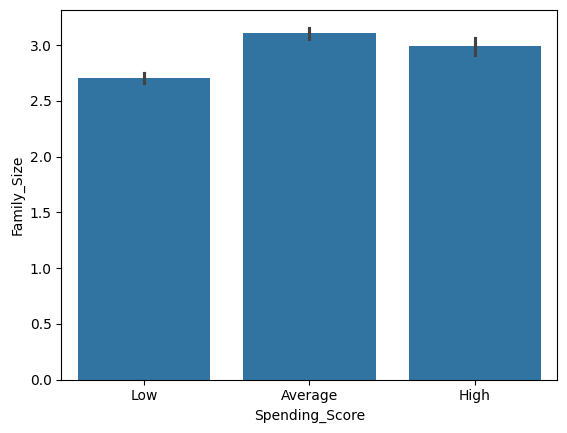

In [13]:
sns.barplot(data=df,x="Spending_Score",y="Family_Size")

<Axes: xlabel='Work_Experience', ylabel='Age'>

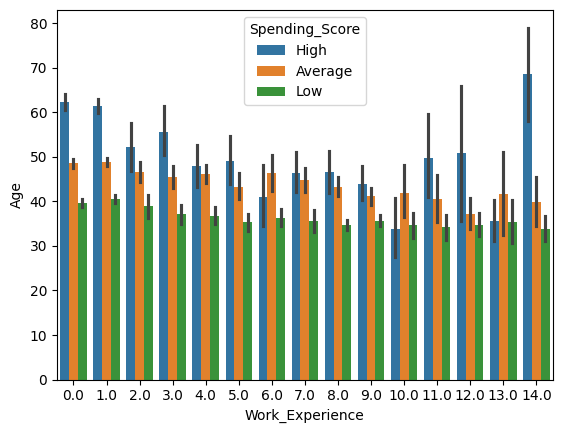

In [14]:
# Age vs Work Experiance 
sns.barplot(data=df,x="Work_Experience",y="Age",hue="Spending_Score")

<Axes: xlabel='count', ylabel='Spending_Score'>

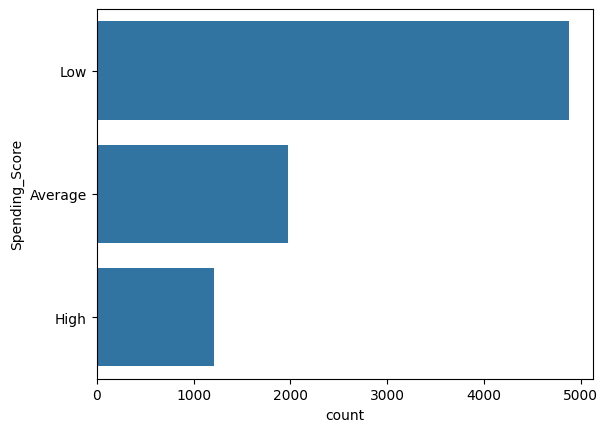

In [15]:
sns.countplot(df['Spending_Score'])

**Select features for clustering**

In [17]:
X = df.drop(['ID' , 'Var_1'],axis=1)

# Data preprocessing

In [19]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [20]:
# Numerical_columns
numerical_cols = ['Age','Work_Experience' ,'Family_Size']

In [21]:
# Categorical columns
categorical_cols = ['Gender' , 'Ever_Married', 'Graduated' , 'Profession' , 'Spending_Score']

**Fill the missing values**

In [23]:
num_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy='median')),
    ("scaler" , StandardScaler())
])

In [24]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("encoding", OneHotEncoder(handle_unknown='ignore'))
])

# Use ColumnTransformer

In [26]:
preprocess = ColumnTransformer([
    ("num" , num_pipeline ,numerical_cols),
    ("cat" , cat_pipeline, categorical_cols)
])

In [27]:
X_process = preprocess.fit_transform(X)

In [28]:
from sklearn.cluster import KMeans

# To find no. of cluster with Elbow Method

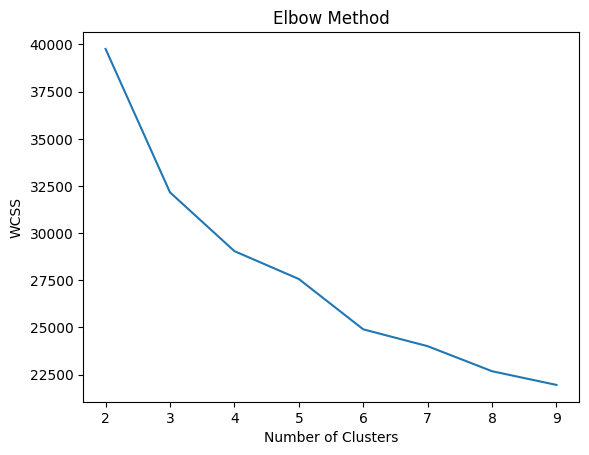

In [43]:
wcss = [] 

k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_process)
    wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Apply algorithm

In [73]:
kmeans_alg = KMeans(n_clusters=3,random_state=42)

In [74]:
cluster = kmeans_alg.fit_predict(X_process)

In [75]:
cluster

array([2, 1, 1, ..., 2, 2, 1], shape=(8068,), dtype=int32)

In [76]:
# Evaluate

In [77]:
from sklearn.metrics import silhouette_score

In [78]:
score = silhouette_score(X_process,cluster)

In [79]:
print(score)

0.2107270820423391


In [39]:
df['Cluster'] = cluster

In [40]:
df['Cluster'].value_counts()

Cluster
1    4024
2    2402
0    1642
Name: count, dtype: int64

In [41]:
df['Cluster'].isnull().sum()

np.int64(0)

In [42]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Cluster
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,2
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,1
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,1
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,1
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,2


In [80]:
df.groupby('Cluster').mean(numeric_only=True)

,ID,Age,Work_Experience,Family_Size
Cluster,,,,
0,463397.115104,37.904994,8.224117,2.461196
1,463496.302187,54.593439,0.917824,2.476899
2,463506.711074,28.629059,1.150870,3.762031


In [91]:
def label_cluster(x):
    if x == 0:
        return "Experienced Professionals"
    elif x == 1:
        return "Senior Customers"
    else:
        return "Young Families"

df['Cluster_Name'] = df['Cluster'].apply(label_cluster)

In [93]:
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Cluster,Cluster_Label,Cluster_Name
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,2,Young Families,Young Families
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,1,Senior Customers,Senior Customers
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,1,Senior Customers,Senior Customers
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,1,Senior Customers,Senior Customers
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,2,Young Families,Young Families
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,2,Young Families,Young Families
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,2,Young Families,Young Families
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,2,Young Families,Young Families
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,2,Young Families,Young Families


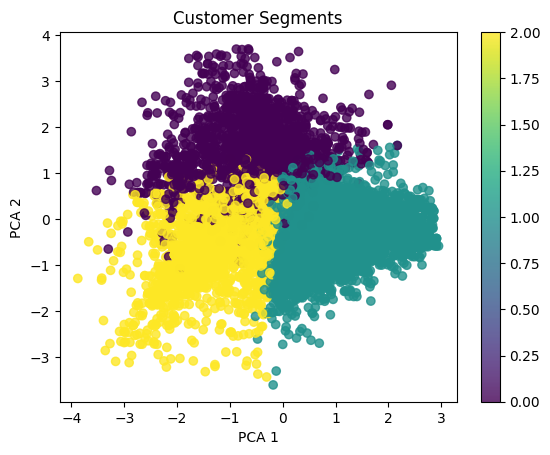

In [98]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_process)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'],alpha=0.8)
plt.title("Customer Segments")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar()
plt.show()

In [99]:
# Model Pipeline

In [101]:
model_pipeline = Pipeline([
    ("preprocessing" , preprocess),
    ("k_means", KMeans(n_clusters=3 ,random_state=42))
])

In [102]:
# fit on raw data
model_pipeline.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('k_means', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

# Save the model

In [105]:
import pickle

pickle.dump(model_pipeline, open("customer_segmentation_pipeline.pkl", "wb"))

In [106]:
# Streamlit App

In [110]:
import streamlit as st
import pickle
import pandas as pd

model = pickle.load(open("customer_segmentation_pipeline.pkl", "rb"))

st.title("Customer Segmentation App")

# Inputs
age = st.number_input("Age")
work_exp = st.number_input("Work Experience")
family_size = st.number_input("Family Size")

gender = st.selectbox("Gender", ["Male", "Female"])
married = st.selectbox("Ever Married", ["Yes", "No"])
graduated = st.selectbox("Graduated", ["Yes", "No"])
profession = st.selectbox("Profession", ["Engineer", "Doctor", "Artist", "Lawyer", "Healthcare"])
spending = st.selectbox("Spending Score", ["Low", "Average", "High"])

if st.button("Predict Cluster"):
    data = pd.DataFrame({
        'Gender':[gender],
        'Ever_Married':[married],
        'Age':[age],
        'Graduated':[graduated],
        'Profession':[profession],
        'Work_Experience':[work_exp],
        'Spending_Score':[spending],
        'Family_Size':[family_size]
    })

    cluster = model.predict(data)[0]

    if cluster == 0:
        label = "Experienced Professionals"
    elif cluster == 1:
        label = "Senior Customers"
    else:
        label = "Young Families"

    st.success(f"Customer belongs to: {label}")

2026-03-29 20:50:45.708 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 20:50:45.714 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 20:50:45.720 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 20:50:45.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 20:50:45.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 20:50:45.735 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 20:50:45.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-29 20:50:45.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar